In [ ]:
from sklearn.datasets import load_wine
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# 1. 데이터 준비
wine = load_wine()
X, y = wine.data, wine.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. 배깅 (bootstrap=True가 기본값)
bag_clf = BaggingClassifier(
    DecisionTreeClassifier(), # 기반이 될 모델 (결정 트리)
    n_estimators=500,         # 모델 500개 생성
    max_samples=100,          # 각 모델당 사용할 샘플 수
    bootstrap=True,           # True면 배깅, False면 페이스팅
    n_jobs=-1,                # 사용 가능한 모든 CPU 코어 사용
    random_state=42
)

bag_clf.fit(X_train, y_train)
y_pred_bag = bag_clf.predict(X_test)

# 3. 페이스팅 (bootstrap=False)
paste_clf = BaggingClassifier(
    DecisionTreeClassifier(),
    n_estimators=500,
    max_samples=100,
    bootstrap=False,      # 비복원 추출
    n_jobs=-1,
    random_state=42
)

paste_clf.fit(X_train, y_train)
y_pred_paste = paste_clf.predict(X_test)
print(f"배깅 정확도: {accuracy_score(y_test, y_pred_bag):.4f}")
print(f"페이스팅 정확도: {accuracy_score(y_test, y_pred_paste):.4f}")

배깅 정확도: 0.9722
페이스팅 정확도: 0.9722


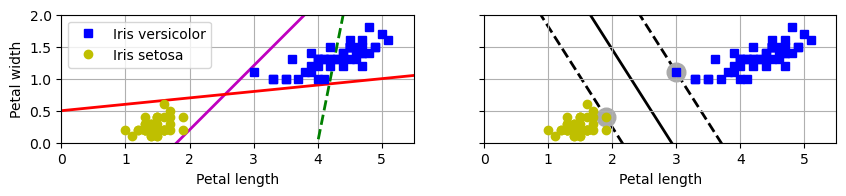

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.svm import SVC
from sklearn import datasets

iris = datasets.load_iris(as_frame=True)
X = iris.data[["petal length (cm)", "petal width (cm)"]].values
y = iris.target

setosa_or_versicolor = (y == 0) | (y == 1)
X = X[setosa_or_versicolor]
y = y[setosa_or_versicolor]

# SVM 분류 모델
svm_clf = SVC(kernel="linear", C=10**9)
svm_clf.fit(X, y)

# 나쁜 모델
x0 = np.linspace(0, 5.5, 200)
pred_1 = 5 * x0 - 20
pred_2 = x0 - 1.8
pred_3 = 0.1 * x0 + 0.5

def plot_svc_decision_boundary(svm_clf, xmin, xmax):
    w = svm_clf.coef_[0]
    b = svm_clf.intercept_[0]

    # 결정 경계에서, w0*x0 + w1*x1 + b = 0
    # => x1 = -w0/w1 * x0 - b/w1
    x0 = np.linspace(xmin, xmax, 200)
    decision_boundary = -w[0] / w[1] * x0 - b / w[1]

    margin = 1/w[1]
    gutter_up = decision_boundary + margin
    gutter_down = decision_boundary - margin
    svs = svm_clf.support_vectors_

    plt.plot(x0, decision_boundary, "k-", linewidth=2, zorder=-2)
    plt.plot(x0, gutter_up, "k--", linewidth=2, zorder=-2)
    plt.plot(x0, gutter_down, "k--", linewidth=2, zorder=-2)
    plt.scatter(svs[:, 0], svs[:, 1], s=180, facecolors='#AAA',
                zorder=-1)

fig, axes = plt.subplots(ncols=2, figsize=(10, 2.7), sharey=True)

plt.sca(axes[0])
plt.plot(x0, pred_1, "g--", linewidth=2)
plt.plot(x0, pred_2, "m-", linewidth=2)
plt.plot(x0, pred_3, "r-", linewidth=2)
plt.plot(X[:, 0][y==1], X[:, 1][y==1], "bs", label="Iris versicolor")
plt.plot(X[:, 0][y==0], X[:, 1][y==0], "yo", label="Iris setosa")
plt.xlabel("Petal length")
plt.ylabel("Petal width")
plt.legend(loc="upper left")
plt.axis([0, 5.5, 0, 2])
plt.gca().set_aspect("equal")
plt.grid()

plt.sca(axes[1])
plot_svc_decision_boundary(svm_clf, 0, 5.5)
plt.plot(X[:, 0][y==1], X[:, 1][y==1], "bs")
plt.plot(X[:, 0][y==0], X[:, 1][y==0], "yo")
plt.xlabel("Petal length")
plt.axis([0, 5.5, 0, 2])
plt.gca().set_aspect("equal")
plt.grid()
plt.show()

In [ ]:
# 결정트리
# 지니계수 , 엔트로피
# 지니계수(불순도) , 엔트로피(불확실성)
# 앙상블 : 배깅 , 부스팅 , 스태킹
# 차원축소 : PCA 차원의 저주 : 차원이 증가할수록 데이터가 희소해지는 현상

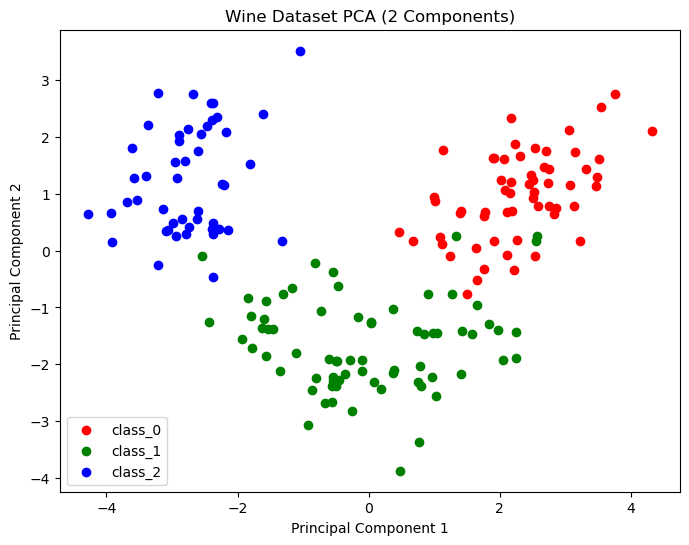

설명된 분산 비율: 0.55


In [3]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import pandas as pd

# 1. 데이터 로드 및 스케일링 (PCA는 스케일링이 필수입니다!)
wine = load_wine()
X_scaled = StandardScaler().fit_transform(wine.data)

# 2. PCA 적용: 13개의 특성을 중요도 순으로 2개로 압축
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 3. 데이터프레임으로 변환하여 시각화 준비
pca_df = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])
pca_df['target'] = wine.target

# 4. 시각화
plt.figure(figsize=(8, 6))
colors = ['r', 'g', 'b']
for target, color in enumerate(colors):
    mask = pca_df['target'] == target
    plt.scatter(pca_df.loc[mask, 'PC1'], pca_df.loc[mask, 'PC2'], c=color, label=wine.target_names[target])

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Wine Dataset PCA (2 Components)')
plt.legend()
plt.show()

# 설명된 분산 비율 확인 (이 2개의 성분이 전체 데이터의 몇 %를 설명하는가?)
print(f"설명된 분산 비율: {pca.explained_variance_ratio_.sum():.2f}")

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(wine.data, wine.target, test_size=0.2, random_state=42)

# 파이프라인 구성: 스케일링 -> PCA(5개로 축소) -> SVC 모델
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=5)), # 13개 중 핵심 정보 5개만 추출
    ('svc', SVC(kernel='linear'))
])

pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)
print(f"차원 축소 후 정확도: {accuracy_score(y_test, y_pred):.4f}")

차원 축소 후 정확도: 1.0000
